# Level 2: Task 1 - Predictive Modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


In [2]:
# Load the data set
df = pd.read_csv('../../level1/task2/cleaned_data.csv')

In [3]:
# Display the number of unique values
df.nunique()

Restaurant ID           9551
Restaurant Name         7446
Country Code              15
City                     141
Address                 8918
Locality                1208
Locality Verbose        1265
Longitude               8120
Latitude                8677
Cuisines                1826
Average Cost for two     140
Currency                  12
Has Table booking          2
Has Online delivery        2
Is delivering now          2
Switch to order menu       1
Price range                4
Aggregate rating          33
Rating color               6
Rating text                6
Votes                   1012
Rating Category            5
dtype: int64

In [4]:
# Drop the high cardinality columns
df.drop(['Restaurant ID', 'Restaurant Name', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude'], axis=1, inplace=True)

In [5]:
# Encode the object columns using label encoder
object_columns = df.select_dtypes(include='object').columns

label_encoder = {}

for col in object_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoder[col] = le

In [6]:
# Specify feature and target variable
X = df.drop('Aggregate rating', axis=1)
y = df['Aggregate rating']

In [7]:
# Split the dataset as train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [8]:
# Initialize the Linear Regression model
lr = LinearRegression()

lr.fit(X_train, y_train)
y_predict_lr = lr.predict(X_test)

# Evaluate the model performance
print("Linear Regression")
print("R2 score:", r2_score(y_test, y_predict_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_predict_lr)))

Linear Regression
R2 score: 0.8504477943634772
RMSE: 0.5834356175019676


In [9]:
# Initialize the Decision Tree model
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_predict_dt = dt.predict(X_test)

# Evaluate the model performance
print('Decision Tree')
print('R2 score', r2_score(y_test, y_predict_dt))
print('RMSE', np.sqrt(mean_squared_error(y_test, y_predict_dt)))

Decision Tree
R2 score 0.9813166733278231
RMSE 0.20621660410216888


In [11]:
# Initialize the Random Forest model
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)
y_predict_rf = rf.predict(X_test)

# Evaluate the model performance
print('Random Forest')
print('R2 score', r2_score(y_test, y_predict_rf))
print('RMSE', np.sqrt(mean_squared_error(y_test, y_predict_rf)))

Random Forest
R2 score 0.9887629146368438
RMSE 0.15992758054805561


In [15]:
# Compare models with their R2 score and RMSE
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
r2_scores = [r2_score(y_test, y_predict_lr), r2_score(y_test, y_predict_dt), r2_score(y_test, y_predict_rf)]
rmse_scores = [np.sqrt(mean_squared_error(y_test, y_predict_lr)), np.sqrt(mean_squared_error(y_test, y_predict_dt)), np.sqrt(mean_squared_error(y_test, y_predict_rf))]

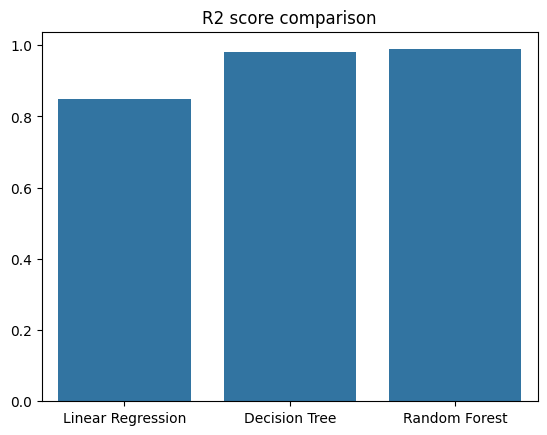

In [13]:
# R2 score comparison
sns.barplot(x=models, y=r2_scores)
plt.title('R2 score comparison')
plt.show()

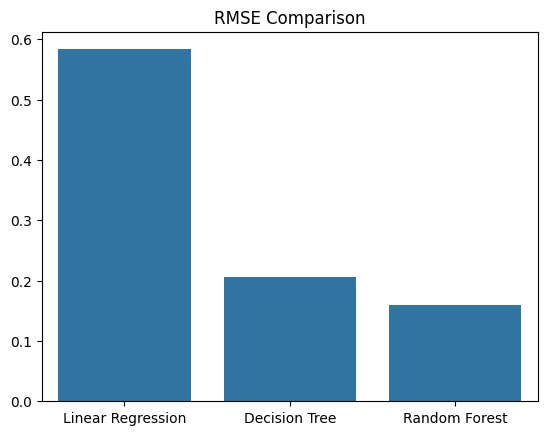

In [14]:
# RMSE comparison
sns.barplot(x=models, y=rmse_scores)
plt.title('RMSE Comparison')
plt.show()

**Random Forest** is the best performer; great balance of accuracy and generalization

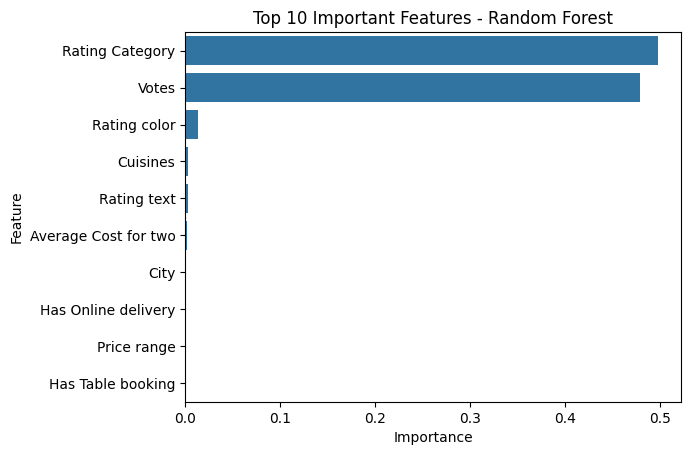

In [16]:
# Feature Importance (Random Forest)
importances = rf.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)

# Plot
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature')
plt.title('Top 10 Important Features - Random Forest')
plt.show()